# MNIST Denoising Autoencoder

## Introduction

This notebook trains a **Convolutional Denoising Autoencoder** on the MNIST
handwritten-digit dataset. Gaussian noise is synthetically added to clean
digit images, and the model learns to map the noisy version back to the
clean original.

It mirrors the same pipeline implemented in the project's `train.py` /
`predict.py` scripts and `utils` / `models` packages, so the notebook can be
used for exploratory analysis while the scripts remain the reproducible
entry points.

**Sections:** Imports → Load Dataset → EDA → Noise Generation → Model →
Training → Evaluation → Visualization → Conclusion.

In [1]:
# --- Imports -----------------------------------------------------------
import os
import sys

sys.path.append(os.path.abspath(".."))  # make the project root importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from utils.config import DEFAULT_CONFIG
from utils.data_loader import load_raw_dataset, save_processed_arrays
from utils.preprocessing import preprocess_pipeline, add_gaussian_noise
from utils.visualization import plot_original_noisy_reconstructed, plot_training_history
from utils.metrics import evaluate_reconstructions
from models.autoencoder import build_autoencoder
from models.trainer import Trainer
from models.predictor import Predictor

config = DEFAULT_CONFIG
config.ensure_directories()

np.random.seed(config.random_seed)
tf.random.set_seed(config.random_seed)

print("TensorFlow version:", tf.__version__)
print(config)

TensorFlow version: 2.16.2
Config(raw_train_csv='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/train.csv', raw_test_csv='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/test.csv', raw_train_dir='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/training', raw_test_dir='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/testing', processed_dir='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/processed', checkpoints_dir='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints', figures_dir='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/figures', logs_dir='/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/logs', history_dir='/Users/dha

## Load Dataset

Loads `train.csv` and `test.csv` from `data/MNIST/raw/` (Kaggle
`awsaf49/mnist-dataset` format: column 0 is the digit label, columns 1-784
are the flattened 28x28 pixel values).

In [2]:
x_train_raw, y_train, x_test_raw, y_test = load_raw_dataset(config)

print("x_train_raw:", x_train_raw.shape)
print("x_test_raw:", x_test_raw.shape)
print("y_train:", y_train.shape, "| unique labels:", np.unique(y_train))

2026-07-04 10:38:10 | utils.data_loader | INFO | Detected image-folder-format raw data.
2026-07-04 10:38:10 | utils.data_loader | INFO | Loading image folder: /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/training (10 class folders)
2026-07-04 10:38:16 | utils.data_loader | INFO | Loaded 60000 images from /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/training
2026-07-04 10:38:16 | utils.data_loader | INFO | Loading image folder: /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/testing (10 class folders)
2026-07-04 10:38:17 | utils.data_loader | INFO | Loaded 10000 images from /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/raw/testing


x_train_raw: (60000, 28, 28)
x_test_raw: (10000, 28, 28)
y_train: (60000,) | unique labels: [0 1 2 3 4 5 6 7 8 9]


## Exploratory Data Analysis (EDA)

A quick look at class balance and a handful of raw sample digits.

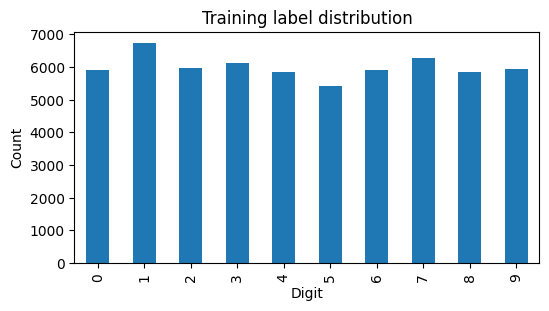

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
pd.Series(y_train).value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Training label distribution")
ax.set_xlabel("Digit")
ax.set_ylabel("Count")
plt.show()

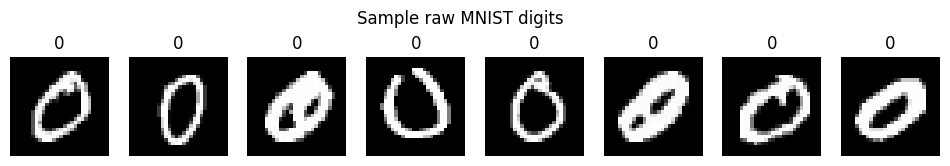

In [4]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train_raw[i], cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.suptitle("Sample raw MNIST digits")
plt.show()

## Noise Generation

Normalize to `[0, 1]`, reshape to `(28, 28, 1)`, then inject Gaussian noise
(`noise_factor = 0.4` by default) and clip back to a valid pixel range.

In [5]:
x_train_clean, x_train_noisy, x_test_clean, x_test_noisy = preprocess_pipeline(
    x_train_raw, x_test_raw, config.noise_factor, config.image_shape, config.random_seed
)

save_processed_arrays(config, x_train_clean, y_train, x_test_clean, y_test)

print("x_train_clean:", x_train_clean.shape, x_train_clean.dtype)
print("x_train_noisy:", x_train_noisy.shape, x_train_noisy.dtype)

2026-07-04 10:38:19 | utils.data_loader | INFO | Saved processed arrays to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/data/MNIST/processed


x_train_clean: (60000, 28, 28, 1) float32
x_train_noisy: (60000, 28, 28, 1) float32


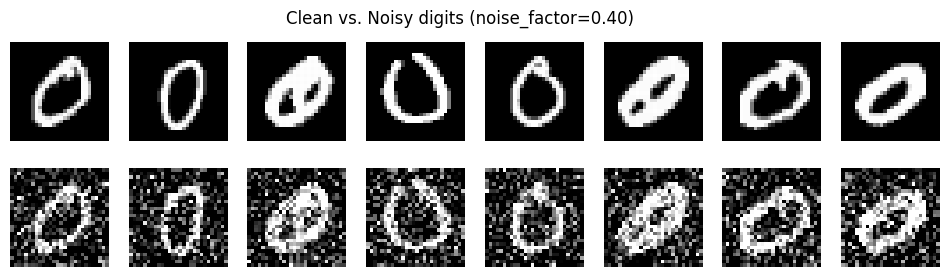

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x_train_clean[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Clean")
axes[1, 0].set_ylabel("Noisy")
plt.suptitle("Clean vs. Noisy digits (noise_factor=%.2f)" % config.noise_factor)
plt.show()

### Optional: comparing several noise factors

Illustrates how reconstruction difficulty scales with the noise factor.

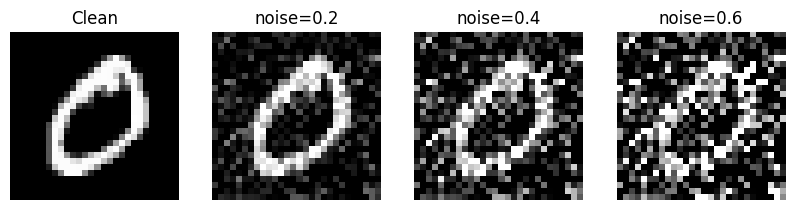

In [7]:
sample_clean = x_train_clean[0]
noisy_versions = {
    factor: add_gaussian_noise(sample_clean[None, ...], factor, config.random_seed)[0]
    for factor in config.noise_factors_to_compare
}

fig, axes = plt.subplots(1, len(noisy_versions) + 1, figsize=(10, 2.5))
axes[0].imshow(sample_clean.squeeze(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean")
axes[0].axis("off")
for ax, (factor, img) in zip(axes[1:], noisy_versions.items()):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"noise={factor}")
    ax.axis("off")
plt.show()

## Model

Convolutional autoencoder built with the Keras Functional API:
`Conv2D -> BatchNorm -> ReLU -> MaxPooling` (encoder, twice) into a latent
bottleneck, then `Conv2D -> UpSampling -> BatchNorm` (decoder, twice) into a
sigmoid `Conv2D(1)` reconstruction head.

In [8]:
autoencoder = build_autoencoder(config.image_shape)
autoencoder.summary()

2026-07-04 10:38:19.891647: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-07-04 10:38:19.892429: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-07-04 10:38:19.892450: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-07-04 10:38:19.892469: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-04 10:38:19.892480: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Conv2D)           │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,193 (438.25 KB)

 Trainable params: 111,809 (436.75 KB)

 Non-trainable params: 384 (1.50 KB)

## Training

Compiled with Adam + binary cross-entropy (MSE also tracked as a metric),
and trained with EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, and
TensorBoard callbacks.

In [9]:
trainer = Trainer(autoencoder, config)
trainer.compile()
history = trainer.fit(x_train_noisy, x_train_clean)
trainer.save_history_csv()
trainer.save_final_model()

2026-07-04 10:38:21 | models.trainer | INFO | Compiled model with optimizer=Adam(lr=1.0e-03), loss=binary_crossentropy
2026-07-04 10:38:21 | models.trainer | INFO | Starting training for up to 50 epochs (batch_size=128)


Epoch 1/50


2026-07-04 10:38:22.629793: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Epoch 1: val_loss improved from None to 0.11965, saving model to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras

Epoch 1: finished saving model to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras
422/422 - 129s - 306ms/step - loss: 0.1162 - mse: 0.0159 - val_loss: 0.1197 - val_mse: 0.0192 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 0.11965 to 0.08794, saving model to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras

Epoch 2: finished saving model to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras
422/422 - 119s - 281ms/step - loss: 0.0885 - mse: 0.0085 - val_loss: 0.0879 - val_mse: 0.0087 - learning_rate: 0.0010
Epoch 3/50



2026-07-04 12:03:00 | models.trainer | INFO | Training complete.
2026-07-04 12:03:00 | models.trainer | INFO | Saved training history to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/history/training_history.csv
2026-07-04 12:03:00 | models.trainer | INFO | Saved model to /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras


'/Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras'

In [10]:
plot_training_history(history.history, metrics=("loss", "mse"))
plt.show()

## Evaluation

Reload the best checkpoint and score reconstructions on the held-out test
set using MSE, PSNR, and SSIM.

In [11]:
predictor = Predictor(config.model_path)
test_reconstructions, report = predictor.denoise_and_evaluate(x_test_noisy, x_test_clean)
print(report)

2026-07-04 12:03:00 | models.predictor | INFO | Loading model from /Users/dhanushyadav/Desktop/Celebel_Assignment/week6/MNIST-Denoising-Autoencoder/outputs/checkpoints/denoising_autoencoder_best.keras
2026-07-04 12:03:04 | models.predictor | INFO | Evaluation on 10000 samples -> MSE=0.006693 | PSNR=22.09 dB | SSIM=0.9182 | n=10000


MSE=0.006693 | PSNR=22.09 dB | SSIM=0.9182 | n=10000


## Visualization

Original vs. noisy vs. reconstructed digits for a random sample of the
test set.

In [13]:
plot_original_noisy_reconstructed(
    x_test_clean, x_test_noisy, test_reconstructions,
    n_samples=10, random_seed=config.random_seed,
)
plt.show()

## Conclusion

- The convolutional denoising autoencoder learns to map Gaussian-corrupted
  MNIST digits back to their clean originals using an encoder-bottleneck-decoder
  architecture trained end-to-end with binary cross-entropy loss.
- Reconstruction quality is quantified with MSE, PSNR, and SSIM, and can be
  benchmarked across different noise factors and loss functions (see
  `README.md` for further experiment ideas).
- The same pipeline is available as reusable, tested modules under
  `utils/` and `models/`, and as CLI entry points in `train.py` / `predict.py`
  for reproducible, script-based runs outside the notebook.